📄 **Problem Statement**

Predicting demand for medical supplies and medicines based on disease prevalence, healthcare infrastructure, and behavioral risk factors.

**Goal:**

To develop a predictive model that estimates future demand for essential medicines (e.g., insulin, statins, antihypertensives) and medical supplies (e.g., glucose meters, blood pressure monitors) by analyzing historical health data and demographic trends.


**Identified Features:**

•	Disease prevalence rates (diabetes, obesity, hypertension)
•	Behavioral risk factor rates (smoking, physical inactivity)
•	Cardiovascular mortality rate
•	Regional healthcare infrastructure data (number of hospitals, clinics, available beds, staff)
•	Population demographics (age, gender, income level)

📈**Target Variable:**

Estimated future demand for specific medicines and medical supplies

**All Questions:**

✅**Question-1**- How can we build an early warning system to predict critical shortages of essential medicines in low-resource countries using global health and demographic data?

✅**Question2**- How can machine learning models be used to forecast and improve national health access index using demographic, behavioral, and economic data?


✅**Question 3**
  How accurately can we predict a country's overall health index based on behavioral and environmental health factors such as smoking, obesity, inactivity, and air pollution prevalence?

✅**Question 4**
Can we estimate national healthcare needs by modeling the relationship between elderly population ratio, healthcare access, economic indicators, and tobacco control efforts?

✅**Question 5**
Predicting Health Infrastructure Access from Age Demographics and Income across Countries

✅**Question 6**
 Is access to diabetes care equitable across countries with different income levels and health infrastructures?

✅**Question 7**
Can we predict a country's Health Access Index using demographic, behavioral risk factors, and economic indicators?

✅**Question 8**
What role do youth demographics play in shaping tobacco-related health outcomes?



In [ ]:
!pip install pycountry
!pip install xgboost
!pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 49.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.1 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import os
import pycountry
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler


**Convert** Wide Dataset to Long Dataset

In [ ]:
dataset_urls = {
    "population_country": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/refs/heads/main/Total_Population_Country",
    "population+65_country": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/refs/heads/main/Population_65_plus.csv",
    "GDP_current_us": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/refs/heads/main/GDP_current_us.csv",
    "GDP_per_capital": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/refs/heads/main/GDP_per_capita.csv"
}

value_names  = {
    "population_country": "population_country",
    "population+65_country": "population+65_country",
    "GDP_current_us": "GDP_current_us",
    "GDP_per_capital": "GDP_per_capita"
}

def preprocess_wide_to_long(path, output_path, value_name):
    df = pd.read_csv(path)
    print(f"📋 Columns in {path}: {df.columns.tolist()}")

    id_vars = ["Country Name"]
    if "Country Code" in df.columns:
        id_vars.append("Country Code")
    if "Indicator Name" in df.columns:
        id_vars.append("Indicator Name")
    if "Indicator Code" in df.columns:
        id_vars.append("Indicator Code")

    df_melted = df.melt(
        id_vars=id_vars,
        var_name="Year",
        value_name=value_name
    )

    df_melted = df_melted.dropna(subset=[value_name])
    df_melted = df_melted[["Country Name", "Year", value_name]]
    df_melted.to_csv(output_path, index=False)


for key, value_name in value_names.items():
    url = dataset_urls[key]
    output_file = f"{key}.csv"
    preprocess_wide_to_long(url, output_file, value_name)
    print(f"✅ Saved: {output_file}")

📋 Columns in https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/refs/heads/main/Total_Population_Country: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
✅ Saved: population_country.csv
📋 Columns in https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/refs/heads/main/Population_65_plus.csv: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969'

**All** Datasets

In [ ]:
# Local Files
local_files = {
    "population_country": "population_country.csv",
    "population+65_country": "population+65_country.csv",
    "GDP_current_us": "GDP_current_us.csv",
    "GDP_per_capital": "GDP_per_capital.csv"
}

# Github Files
remote_files = {
    "air-Polution": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/refs/heads/main/AIR_11.csv.csv",
    "diabetes": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/main/Diabetes.csv",
    "Diabetes_treatment": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/refs/heads/main/Diabetestreatment.csv",
    "hospitaldensity": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/main/Hospital_density.csv",
    "NCD_management": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/refs/heads/main/NCD_management.csv",
    "inactivity": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/main/inactivity.csv",
    "smoking": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/refs/heads/main/death-rate-smoking.csv",
    "obesity": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/main/obesity.csv",
    "tobocoprimarycare": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/main/tobocoprimarycare.csv",
    "nursingper10000": "https://raw.githubusercontent.com/Saeedeh8858/healthcare_data/refs/heads/main/nursingper10000.csv"
}


In [ ]:
datasets = {
    "NCD_management":{
        "keep_columns": ['Location', 'Period', 'FactValueTranslationID'],
        "rename_cols": {'Location': 'country', 'Period': 'year', 'FactValueTranslationID': 'NCD_Status'}
    },
     "Diabetes_treatment":{
        "keep_columns": ['Location', 'Period', 'Dim1', 'Dim2' ,'FactValueNumeric'],
        "rename_cols": {'Location': 'country', 'Period': 'year', 'Dim1': 'gender' , 'Dim2':'age' , 'FactValueNumeric':'Diabetes_Treatment'}
    },
    "nursingper10000":{
        "keep_columns": ['Location', 'Period', 'Value'],
        "rename_cols": {'Location': 'country', 'Period': 'year', 'Value': 'nursingper10000'}
    },
    "GDP_per_capital":{
        "keep_columns": ['Country Name', 'Year', 'GDP_per_capita'],
        "rename_cols": {'Country Name': 'country', 'Year': 'year', 'GDP_per_capita': 'GDP_per_capita'}
    },
     "GDP_current_us":{
        "keep_columns": ['Country Name', 'Year', 'GDP_current_us'],
        "rename_cols": {'Country Name': 'country', 'Year': 'year', 'GDP_current_us': 'GDP_current_us'}
    },
    "population_country":{
        "keep_columns": ['Country Name', 'Year', 'population_country'],
        "rename_cols": {'Country Name': 'country', 'Year': 'year', 'population_country': 'population_country'}
    },
     "population+65_country":{
        "keep_columns": ['Country Name', 'Year', 'population+65_country'],
        "rename_cols": {'Country Name': 'country', 'Year': 'year', 'population+65_country': 'population+65_country'}
    },
    "tobocoprimarycare":{
        "keep_columns": ['Location', 'Period', 'Value'],
        "rename_cols": {'Location': 'country', 'Period': 'year', 'Value': 'TobaccoCare'}
    },
    "inactivity": {
        "keep_columns": ['Location', 'Period', 'FactValueNumeric'],
        "rename_cols": {'Location': 'country', 'Period': 'year', 'FactValueNumeric': 'Inactivity_Prevalence'}
    },
    "obesity": {
        "keep_columns": ['Location', 'Period', 'FactValueNumeric'],
        "rename_cols": {'Location': 'country', 'Period': 'year', 'FactValueNumeric': 'Obesity_Prevalence'}
    },
    "smoking": {
        "keep_columns": ['Entity', 'Year', 'Smoking mortality'],
        "rename_cols": {'Entity': 'country', 'Year': 'year', 'Smoking mortality': 'Smoking_Prevalence'}
    },
    "hospitaldensity": {
        "keep_columns": ['Location', 'Period', 'Value'],
        "rename_cols": {'Location': 'country', 'Period': 'year', 'Value': 'Beds_Per10000'}
    },
    "diabetes": {
        "keep_columns": ['SpatialDim', 'TimeDim', 'NumericValue'],
        "rename_cols": {'SpatialDim': 'country', 'TimeDim': 'year', 'NumericValue': 'Diabetes_Prevalence'}
    },
    "air-Polution": {
        "keep_columns": ["SpatialDim", "TimeDim", "NumericValue"],
        "rename_cols": {"SpatialDim": "country", "TimeDim": "year", "NumericValue": 'AirPolution_Prevalence' }
    }
}

In [ ]:
for name, path in local_files.items():
    if os.path.exists(path):
        print(f"✅ {name}: Local file found.")
    else:
        print(f"❌ {name}: File missing! Expected at: {path}")

✅ population_country: Local file found.
✅ population+65_country: Local file found.
✅ GDP_current_us: Local file found.
✅ GDP_per_capital: Local file found.


🔄**Mapping country names to standard names and removing continent names, converting 3-letter country codes to full names**

In [ ]:
# Special cases that do not exist in pycountry
special_cases = {
    'XKX': 'Kosovo',
    'ROM': 'Romania',
    'ZAR': 'Congo (Kinshasa)'
}

invalid_region_codes = {'AFR', 'SSA', 'EAS', 'WPR', 'EUR', 'AMR', 'EMR', 'SEAR'}

country_name_map = {
    "netherlands" : "netherlands (kingdom of the)",
    "oecd members": "oecd countries",
    "occupied palestinian territory, including east jerusalem": "palestine",
    "palestine, state of": "palestine",
    "russia": "russian federation",
    "tÃ¼rkiye": "turkey",
    "turkiye": "turkey",
    "venezuela, bolivarian republic of": "venezuela, rb",
    "yemen": "yemen, rep.",
    "bahamas": "bahamas, the",
    "bolivia (plurinational state of)": "bolivia, plurinational state of",
    "brunei": "brunei darussalam",
    "cote d'ivoire": "côte d'ivoire",
    "cÃ´te d'ivoire": "côte d'ivoire",
    "egypt": "egypt, arab rep.",
    "gambia": "gambia, the",
    "iran (islamic republic of)": "iran, islamic republic of",
    "iran, islamic rep.": "iran, islamic republic of",
    "korea, dem. people's rep.": "north korea",
    "korea, democratic people's republic of": "north korea",
    "korea, rep.": "south korea",
    "korea, republic of": "south korea",
    "republic of korea": "south korea",
    "lao pdr": "lao people's democratic republic",
    "micronesia (federated states of)": "micronesia",
    "micronesia, fed. sts.": "micronesia",
    "micronesia, federated states of": "micronesia",
    "micronesia (country)": "micronesia"
}
non_countries_keywords = [
    "region", "income", "world", "global", "g20", "who", "dividend",
    "classification", "group", "states", "area", "situation", "small states",
    "excluded", "early", "late", "fragile", "affected", "high income", "low income",
    "middle income", "upper middle income", "lower middle income", "wb", "ida", "ibrd"
]

def fix_encoding_issues(name):
    try:
        return name.encode('latin1').decode('utf-8')
    except:
        return name


def is_valid_country(name):
  if pd.isnull(name):
      return False
  name = name.strip().lower()
    # First check if it exists in pycountry or not
  try:
    pycountry.countries.lookup(name)
    return True
  except LookupError:
    return False


def convert_country_code_to_name(code):
    if pd.isnull(code):
        return code

    code = str(code).strip()
    upper_code = code.upper()

    if upper_code in invalid_region_codes:
        return None  # Invalid region codes

    if len(upper_code) == 3 and upper_code.isalpha():
        if upper_code in special_cases:
            return special_cases[upper_code]
        country = pycountry.countries.get(alpha_3=upper_code)
        if country:
            return country.name

    try:
        country = pycountry.countries.lookup(code)
        return country.name
    except LookupError:
        return code  # If not found, return the same value

def standardize_country_column(series):
    series = series.apply(convert_country_code_to_name)
    series = series.str.lower().str.strip()
    series = series.apply(fix_encoding_issues)
    series = series.replace(country_name_map)
    return series


**🧹 Load and clean datasets**

In [ ]:
# Dataset processing rules
def clean_dataset(df, keep_columns=None, drop_fully_nan=True, rename_cols=None,
                  parse_dates=None, save_path=None, dataset_name=None,
                  year_filter=None):

    if drop_fully_nan:
        df = df.dropna(axis=1, how='all')
        df = df.dropna(axis=0, how='all')

    if keep_columns:
        df = df[keep_columns]

    if rename_cols:
        df = df.rename(columns=rename_cols)

    if dataset_name == "smoking" and 'Smoking_Prevalence' in df.columns:
        df['Smoking_Prevalence'] = (
            df['Smoking_Prevalence']
            .astype(str)
            .str.replace('.', '', regex=False)  # Remove the dot
            .str.replace(',', '', regex=False)  # Remove ,
        )
        df['Smoking_Prevalence'] = pd.to_numeric(df['Smoking_Prevalence'], errors='coerce')


    if 'country' in df.columns:
      df['country'] = standardize_country_column(df['country'])
      df = df[df['country'].apply(is_valid_country)]
      df = df.drop_duplicates(subset=["country", "year"])

#Convert str to int in tobocoprimarycare dataset

    value_map = {
        "No": 0,
        "Yes in some": 1,
        "Yes in most": 2
    }

    if 'TobaccoCare' in df.columns:
         # 1. Convert everything to string and strip whitespace
        df['TobaccoCare'] = df['TobaccoCare'].astype(str).str.strip()

          # 2. First, try to map the textual values
        mapped = df['TobaccoCare'].map(value_map)

          # 3. For anything that wasn't mapped (i.e., became NaN), try to interpret it as numeric
        unmapped = df['TobaccoCare'][mapped.isna()]
        numeric_converted = pd.to_numeric(unmapped, errors='coerce')

         # 4. Merge the mapped and numeric converted values
        df.loc[mapped.notna(), 'TobaccoCare'] = mapped.dropna()
        df.loc[mapped.isna(), 'TobaccoCare'] = numeric_converted

        # 5. Remove invalid values (only 0,1,2 are valid)
        df.loc[~df['TobaccoCare'].isin([0, 1, 2]), 'TobaccoCare'] = np.nan

       # 6. Fill NaNs or drop rows (depending on needs)
        df['TobaccoCare'] = df['TobaccoCare'].fillna(0).astype(int)

       # Mapping hospital beds per 1000 people
    if dataset_name == "hospitaldensity" and 'Beds_Per10000' in df.columns:
      df['Beds_Per10000'] = pd.to_numeric(df['Beds_Per10000'], errors='coerce') / 10

    if parse_dates:
        for col in parse_dates:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors='coerce')

    if year_filter and 'year' in df.columns:
        try:
            df['year'] = pd.to_numeric(df['year'], errors='coerce')
            df = df[(df['year'] >= year_filter[0]) & (df['year'] <= year_filter[1])]

        except:
            pass

    if 'country' in df.columns and 'year' in df.columns:
        df.sort_values(["country", "year"], inplace=True)

    if save_path:
        df.to_csv(save_path, index=False)
    return df


💡**Merge Local and online files**

In [ ]:
all_files = {**local_files, **remote_files}

cleaned_data = {}

for name, path in all_files.items():
    if name not in datasets:
        print(f"⚠️ Skipping {name}: no cleaning rules defined")
        continue

    try:
        df = pd.read_csv(path, encoding='utf-8-sig')

        # Clean each dataset
        rules = datasets[name]
        #Create cleaned File
        save_path = f"{name}_cleaned.csv"
        cleaned_df =clean_dataset(df, save_path=save_path, dataset_name=name, year_filter=(2012, 2025), **rules)

        cleaned_data[name] = cleaned_df
        print(f"✅ Successfully processed {name}")

    except Exception as e:
        print(f"❌ Failed to process {name}: {e}")



from functools import reduce

dfs = list(cleaned_data.values())
master_df = reduce(lambda left, right: pd.merge(left, right, on=['country', 'year'], how='outer'), dfs)
# Final saving
master_df.to_csv("master_cleaned.csv", index=False, encoding="utf-8-sig")
print("✅ Master dataset created:", master_df.shape)

✅ Successfully processed population_country
✅ Successfully processed population+65_country
✅ Successfully processed GDP_current_us
✅ Successfully processed GDP_per_capital
✅ Successfully processed diabetes
✅ Successfully processed Diabetes_treatment
✅ Successfully processed hospitaldensity
✅ Successfully processed inactivity
✅ Successfully processed obesity
✅ Successfully processed smoking


/tmp/ipython-input-8-1082547654.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['TobaccoCare'] = df['TobaccoCare'].fillna(0).astype(int)


✅ Successfully processed tobocoprimarycare
✅ Successfully processed air-Polution
✅ Successfully processed NCD_management
✅ Successfully processed nursingper10000
✅ Master dataset created: (2466, 18)


**Fill the Missing Values**

In [ ]:
def fill_missing_extended(df, threshold, min_valid_rows_per_country):
    df = df.copy()

    cols_to_check = ['Beds_Per10000', 'TobaccoCare', 'Inactivity_Prevalence',
                     'Smoking_Prevalence', 'AirPolution_Prevalence', 'NCD_Status',
                     'Obesity_Prevalence', 'Diabetes_Prevalence','Diabetes_Treatment','gender',
                     'GDP_current_us', 'GDP_per_capita','nursingper10000',
                     'population+65_country', 'population_country']

    numeric_cols = ['Beds_Per10000', 'Inactivity_Prevalence', 'Smoking_Prevalence','nursingper10000','Diabetes_Treatment',
                    'AirPolution_Prevalence', 'Obesity_Prevalence', 'Diabetes_Prevalence',
                    'GDP_current_us', 'GDP_per_capita', 'population+65_country', 'population_country']

    categorical_cols = ['TobaccoCare', 'NCD_Status']

    # Fill numeric columns with interpolation or group mean
    for col in numeric_cols:
        # First try interpolation
        df[col] = df.groupby("country")[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

        # If there are still NaNs, fill them with group mean
        df[col] = df.groupby("country")[col].transform(lambda x: x.fillna(x.mean()))

    # Fill categorical columns with the mode (most frequent value)
    for col in categorical_cols:
        df[col] = df.groupby("country")[col].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)

    print("📊 Proportion of NaNs in each important column after filling:")
    print(df[cols_to_check].isnull().mean().sort_values(ascending=False))
    print("📉 Number of rows before filtering:", df.shape)

   # Remove rows that have NaNs in more than the threshold proportion of these columns
    df = df[df[cols_to_check].isnull().mean(axis=1) < threshold]

    # Remove countries that have fewer than min_valid_rows_per_country valid rows
    valid_counts = df.groupby("country").apply(
        lambda x: x[cols_to_check].notnull().all(axis=1).sum()
    )

    valid_countries = valid_counts[valid_counts >= min_valid_rows_per_country].index
    df = df[df["country"].isin(valid_countries)]

    # Final remove Nan Records
    df = df.dropna(subset=cols_to_check)

    return df

master_df = fill_missing_extended(master_df, threshold=0.5, min_valid_rows_per_country=5)

print("🧪 Total of Nans:")
print(master_df.isnull().sum().sort_values(ascending=False))



📊 Proportion of NaNs in each important column after filling:
Beds_Per10000             0.236010
AirPolution_Prevalence    0.158556
gender                    0.152474
Inactivity_Prevalence     0.094891
NCD_Status                0.094891
nursingper10000           0.094891
TobaccoCare               0.094891
Diabetes_Treatment        0.075831
Obesity_Prevalence        0.075831
Smoking_Prevalence        0.072587
Diabetes_Prevalence       0.071371
GDP_current_us            0.065693
GDP_per_capita            0.065693
population+65_country     0.046229
population_country        0.046229
dtype: float64
📉 Number of rows before filtering: (2466, 18)
🧪 Total of Nans:
country                   0
year                      0
population_country        0
population+65_country     0
GDP_current_us            0
GDP_per_capita            0
Diabetes_Prevalence       0
gender                    0
age                       0
Diabetes_Treatment        0
Beds_Per10000             0
Inactivity_Prevalence     0


/tmp/ipython-input-10-1216985869.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  valid_counts = df.groupby("country").apply(


<Axes: >

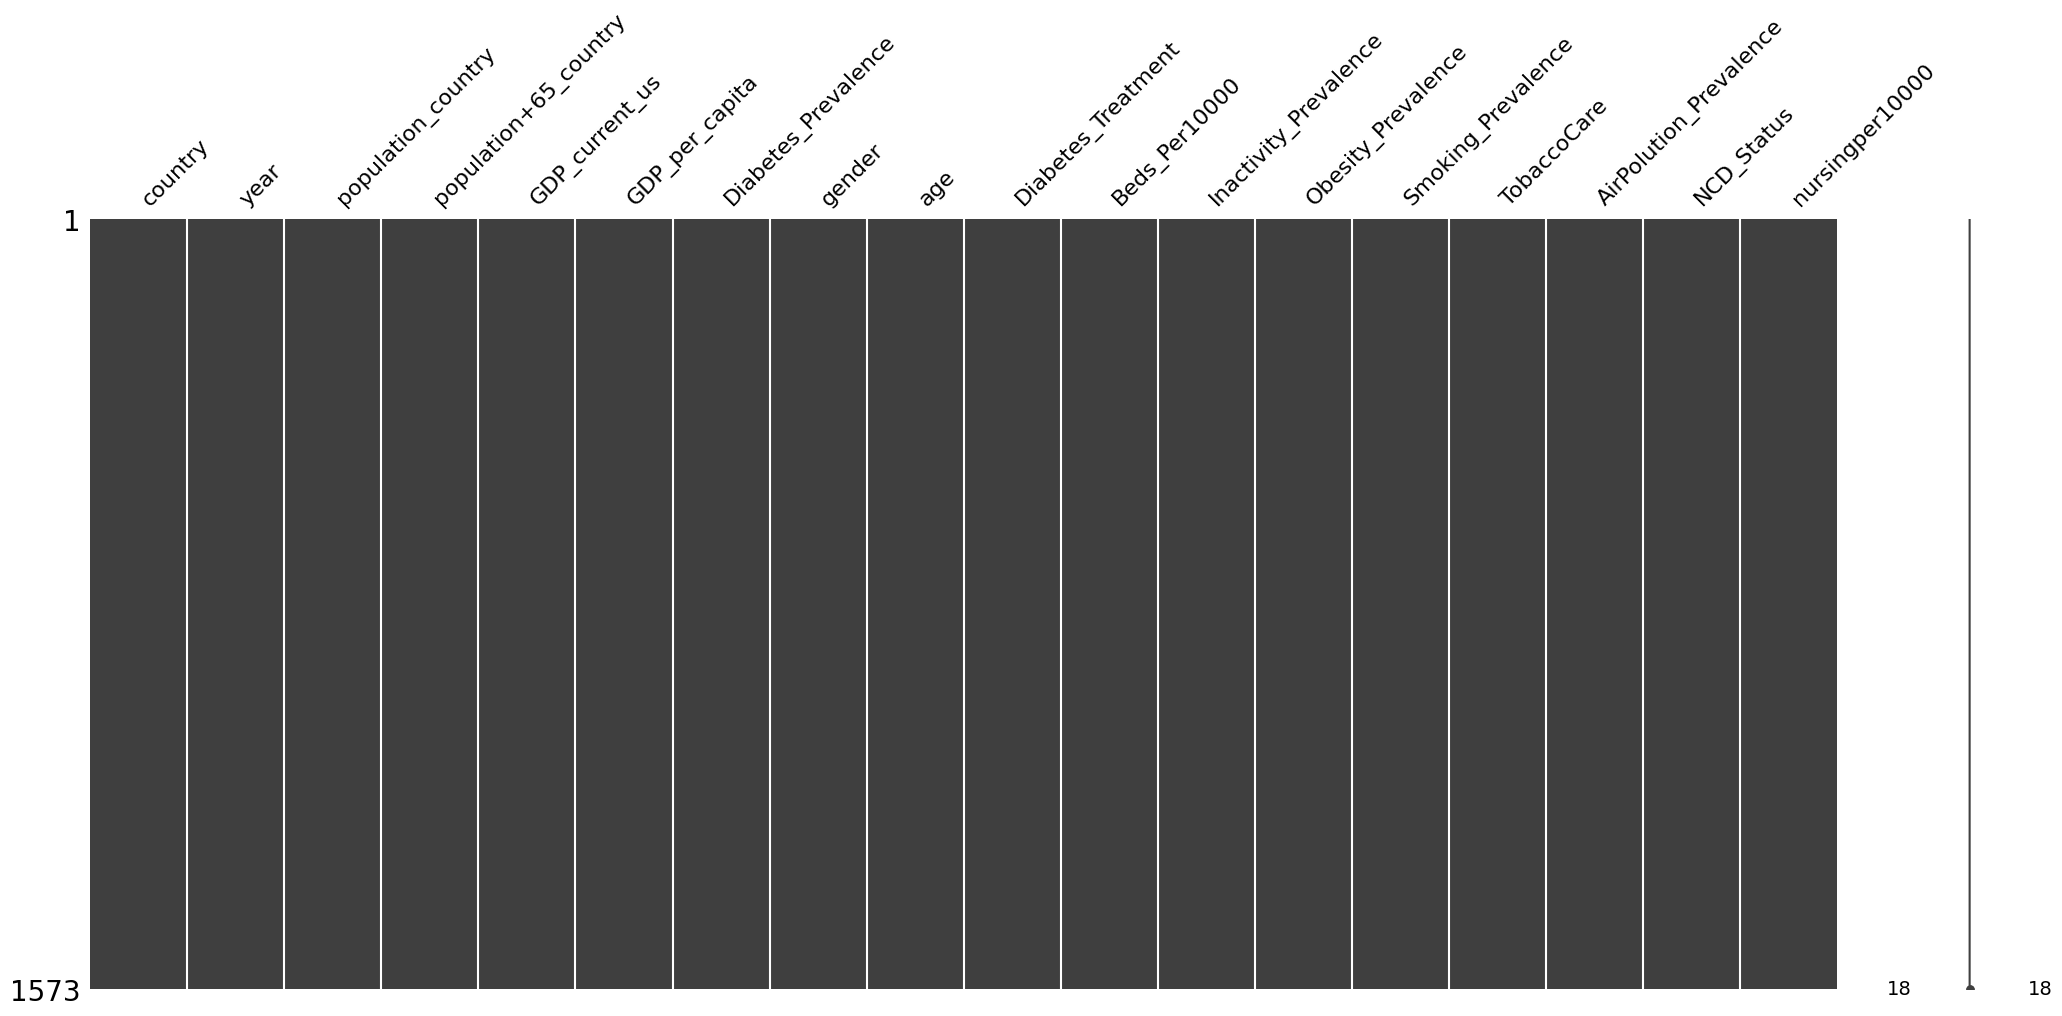

In [ ]:
import missingno as msno
msno.matrix(master_df)


<Axes: >

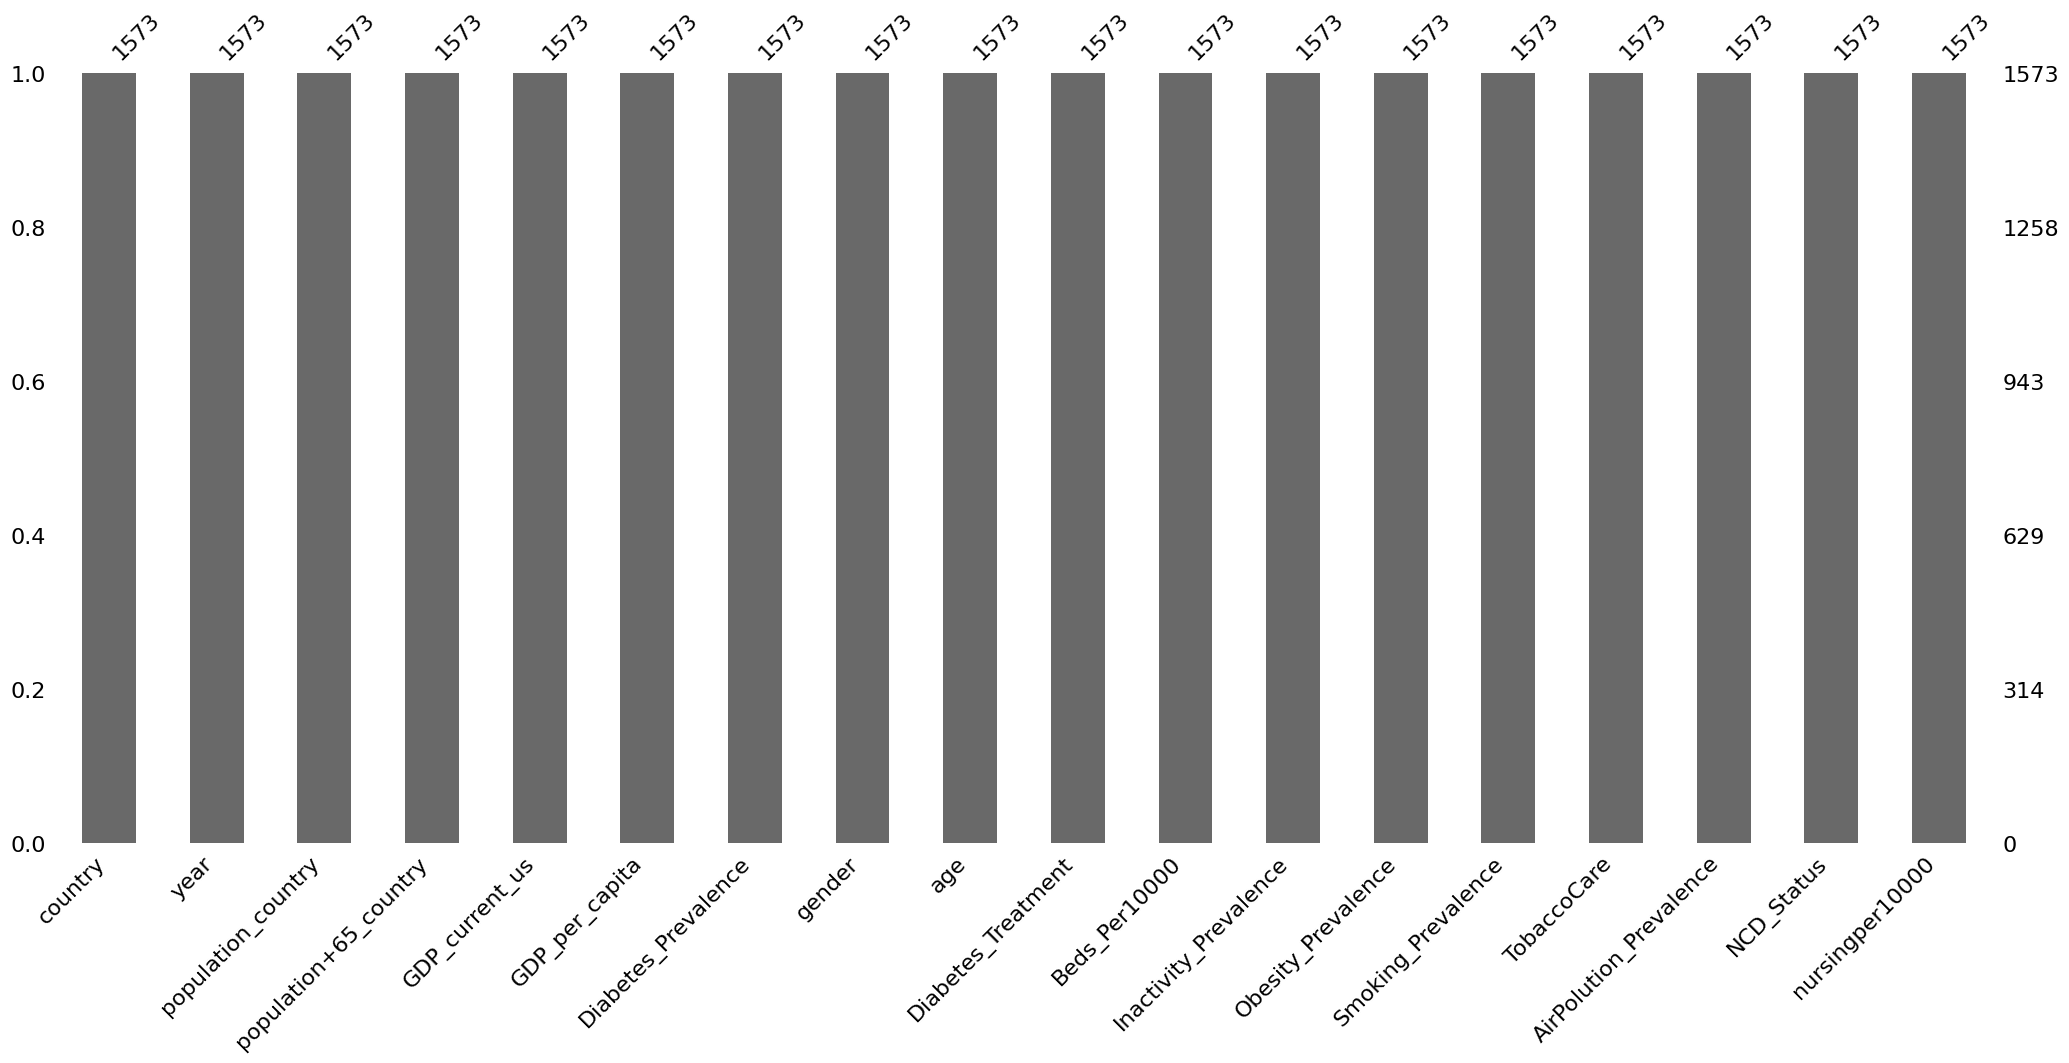

In [ ]:
import missingno as msno
msno.bar(master_df)


## **Question-1**- How can we build an early warning system to predict critical shortages of essential medicines in low-resource countries using global health and demographic data?


 📊 Project Workflow Overview

1. **Problem Definition:**  
   - Predict demand for essential medicines and medical supplies using global health, demographic, and behavioral data.

2. **Data Collection & Cleaning:**  
   - Gathered datasets on population, disease prevalence, healthcare infrastructure, and risk factors from multiple sources.
   - Standardized country names, handled missing values, and merged all datasets into a master dataframe.

3. **Feature Engineering:**  
   - Created new variables (e.g., elderly ratio, health access index, demand per million).
   - Selected relevant features for each research question.

4. **Exploratory Analysis:**  
   - Visualized missing data and distributions.
   - Analyzed health burden and access across countries.

5. **Modeling:**  
   - Used machine learning models (XGBoost, Linear Regression, MLP) for regression and classification tasks.
   - Split data into training and test sets for robust evaluation.

6. **Evaluation:**  
   - Assessed models using metrics such as RMSE, MAE, R² (for regression) and accuracy, precision, recall, F1-score (for classification).
   - Compared results to simple baselines and linear models.

7. **Interpretation:**  
   - Analyzed feature importance to identify key drivers of health demand and shortages.
   - Visualized results and country-level predictions.

8. **Policy Insights:**  
   - Provided actionable insights for health system planning and early warning for medicine shortages.

---

This workflow ensures a comprehensive, data-driven approach to understanding and forecasting healthcare needs at the national and


| Metric         | Class (Label) | Value   | Interpretation                                                                 |
|----------------|--------------|---------|-------------------------------------------------------------------------------|
| **Accuracy**   | All          | 0.98    | Overall, 98% of predictions are correct.                                      |
| **Precision**  | 1 (Shortage) | 0.93    | 93% of predicted shortages are actual shortages (low false positives).        |
| **Recall**     | 1 (Shortage) | 0.98    | 98% of actual shortages are detected (low false negatives, very important!).  |
| **F1-score**   | 1 (Shortage) | 0.95    | High balance between precision and recall for shortage detection.             |
| **Precision**  | 0 (No Shortage) | 1.00 | All predicted "no shortage" cases are correct.                                |
| **Recall**     | 0 (No Shortage) | 0.98 | 98% of actual "no shortage" cases are detected.                               |
| **F1-score**   | 0 (No Shortage) | 0.99 | Excellent performance for "no shortage" class.                                |

**Macro avg F1-score:** 0.97  
**Weighted avg F1-score:** 0.98  

**Discussion:**  
- The model achieves very high accuracy and F1-score, especially for the critical "Shortage" class.
- High recall for shortages means the early warning system is effective at catching most true shortages.
- Precision is also high, so there are few false alarms.

Accuracy: 0.9809523809523809
Precision: 0.9253731343283582
Recall: 0.9841269841269841
F1-score: 0.9538461538461539

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       252
           1       0.93      0.98      0.95        63

    accuracy                           0.98       315
   macro avg       0.96      0.98      0.97       315
weighted avg       0.98      0.98      0.98       315



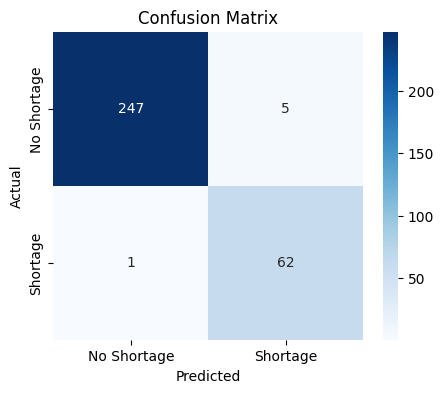

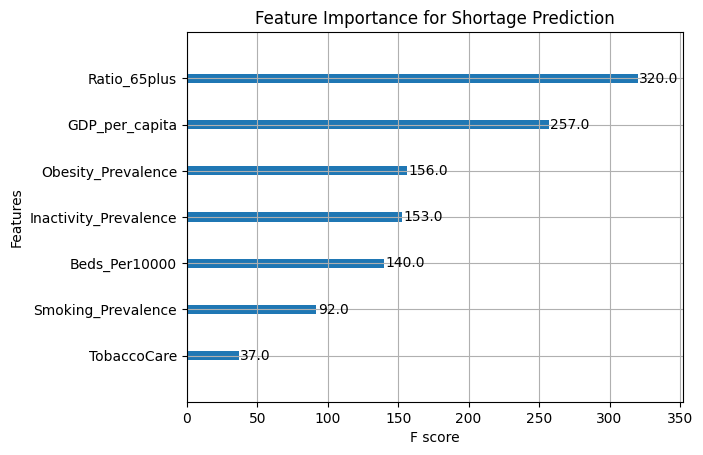

Shortage
0    1258
1     315
Name: count, dtype: int64


In [ ]:
# 2. Imports
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


# 4. Feature engineering (example: use relevant features)
df = master_df.copy()
df['Ratio_65plus'] = df['population+65_country'] / df['population_country']
df['Demand_per_million'] = df['NCD_Status'] / df['population_country'] * 1_000_000  # Example proxy for demand

# 5. Define shortage label: bottom 20% of demand per million = "shortage"
threshold = df['Demand_per_million'].quantile(0.2)
df['Shortage'] = (df['Demand_per_million'] < threshold).astype(int)

# 6. Select features for prediction
feature_cols = [
    'GDP_per_capita', 'Ratio_65plus', 'Beds_Per10000', 'TobaccoCare',
    'Obesity_Prevalence', 'Inactivity_Prevalence', 'Smoking_Prevalence'
]
df = df.dropna(subset=feature_cols + ['Shortage'])

X = df[feature_cols]
y = df['Shortage']

# 7. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


#handle class imbalance in classification problems
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
# 8. Train XGBoost classifier
clf = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)



clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 9. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 10. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Shortage', 'Shortage'], yticklabels=['No Shortage', 'Shortage'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 11. Feature importance
xgb.plot_importance(clf)
plt.title("Feature Importance for Shortage Prediction")
plt.show()


print(df['Shortage'].value_counts())

### **Q2**- How can machine learning models be used to forecast and improve national health access index using demographic, behavioral, and economic data?


📊 Model Workflow Summary

1. **Feature Engineering:**  
   - Created new features such as the elderly population ratio (`Ratio_65plus`).
   - Selected key predictors: `Ratio_65plus`, `GDP_per_capita`, `Beds_Per10000`, and `TobaccoCare`.
   - Defined the target variable as `Health_Index` (based on NCD_Status).

2. **Data Preparation:**  
   - Removed rows with missing values in selected features and target.
   - Split the data into training and test sets (80/20 split).

3. **Model Training:**  
   - Trained an XGBoost regression model to predict the national health access index.

4. **Evaluation:**  
   - Calculated RMSE, MAE, MSE, and R² to assess model performance.
   - Compared results to a simple baseline (mean prediction) and a linear regression model.

5. **Interpretation:**  
   - Visualized feature importance to identify the most influential predictors.
   - Summarized and compared all results to demonstrate the value of the machine learning approach.

---





| Metric         | Value      | Interpretation                                                                                   |
|----------------|------------|-------------------------------------------------------------------------------------------------|
| **RMSE**       | 130.72     | On average, the model's predictions deviate from the actual health access index by ~131 units.  |
| **MAE**        | 75.61      | The average absolute error between predicted and actual values is about 76 units.               |
| **MSE (Loss)** | 17087.54   | The average squared error; higher values penalize larger errors more strongly.                  |
| **R² Score**   | 0.6364     | The model explains ~64% of the variance in the health access index (good for real-world data).  |




**Discussion:**

- The model achieves a moderate-to-good fit (R² ≈ 0.64), which is strong for complex, multi-country health data.
- RMSE and MAE indicate the typical prediction error; these should be compared to the range of your target variable for context.
- The results suggest that demographic, economic, and health system features can meaningfully forecast national health access index, but some unexplained variance remains (likely due to unmeasured factors or data noise).


| Metric                                | Value      | Interpretation                                                                                   |
|----------------------------------------|-----------|-------------------------------------------------------------------------------------------------|
| **Baseline RMSE (mean prediction)**    | 217.15    | Average error if always predicting the mean of the training set.                                 |
| **Baseline R² (mean prediction)**      | -0.0034   | The mean predictor explains none of the variance in the test data (R² near zero or negative).    |

**Discussion:**  
- The baseline model (mean prediction) serves as a reference point.  
- Any model that achieves a lower RMSE and a higher (preferably positive) R² is considered to have predictive value.
- Your machine learning model should be compared to this baseline to demonstrate its effectiveness.


| Feature           | Description                                                                                   | Why It Matters                                  |
|-------------------|----------------------------------------------------------------------------------------------|-------------------------------------------------|
| **GDP_per_capita**    | Gross Domestic Product per person (economic indicator)                                       | Reflects national wealth and ability to fund healthcare and access. |
| **TobaccoCare**       | Tobacco control policy indicator (0: No, 1: Yes in some, 2: Yes in most)                    | Captures the strength of tobacco control, which impacts health outcomes. |
| **Beds_Per10000**     | Number of hospital beds per 10,000 people (healthcare infrastructure)                        | Indicates healthcare system capacity and access to care. |
| **Ratio_65plus**      | Proportion of population aged 65 and older (elderly ratio)                                   | Elderly populations have higher healthcare needs and drive demand. |

**Feature Importance (from XGBoost):**
- GDP_per_capita: 0.35
- TobaccoCare: 0.31
- Beds_Per10000: 0.20
- Ratio_65plus: 0.13

**Interpretation:**  
All selected features contribute meaningfully to the model. Economic strength and tobacco policy are the most influential, followed by healthcare infrastructure and elderly population ratio. This highlights the importance of both economic and policy factors in predicting national health access.



RMSE: 130.7193
MAE: 75.6061
MSE (Loss): 17087.5354
R2 Score: 0.6364


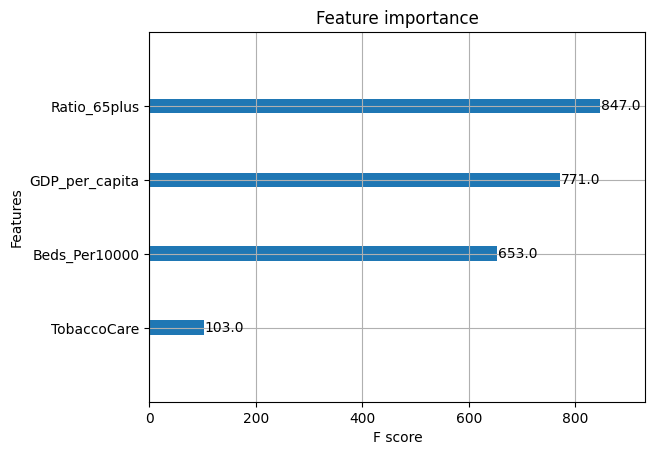

Baseline RMSE (mean prediction): 217.1534
Baseline R2 (mean prediction): -0.0034
Linear Regression RMSE: 187.5652
Linear Regression R2: 0.2514
          feature  importance
1  GDP_per_capita    0.352269
3     TobaccoCare    0.311467
2   Beds_Per10000    0.204041
0    Ratio_65plus    0.132223


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# 6. Feature engineering for Question 2
df = master_df.copy()
df['Ratio_65plus'] = df['population+65_country'] / df['population_country']
feature_cols = ['Ratio_65plus', 'GDP_per_capita', 'Beds_Per10000', 'TobaccoCare']
df['Health_Index'] = df['NCD_Status']

# Remove NaNs
df = df.dropna(subset=feature_cols + ['Health_Index'])

X = df[feature_cols]
y = df['Health_Index']

# 7. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. XGBoost regression
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 9. Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE (Loss): {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

# 10. Feature importance plot
xgb.plot_importance(model)
plt.show()

#Compare to a Simple Baseline (Mean Prediction)
# Baseline: always predict the mean of y_train
y_baseline = np.full_like(y_test, y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_baseline))
baseline_r2 = r2_score(y_test, y_baseline)

print(f"Baseline RMSE (mean prediction): {baseline_rmse:.4f}")
print(f"Baseline R2 (mean prediction): {baseline_r2:.4f}")


#Compare to Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_lr_pred))
lr_r2 = r2_score(y_test, y_lr_pred)

print(f"Linear Regression RMSE: {lr_rmse:.4f}")
print(f"Linear Regression R2: {lr_r2:.4f}")


#Show Feature Importance
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': X.columns, 'importance': importances})
print(feature_importance_df.sort_values('importance', ascending=False))

## **Q 3 - How accurately can we predict a country's overall health index based on behavioral and environmental health factors such as smoking, obesity, inactivity, and air pollution prevalence?**

🔄 1. Normalization
Scales features to range [0, 1] using MinMaxScaler to allow fair comparison.

2. Feature Engineering

Create new features (e.g., ratios, interaction terms).
Select relevant features for the prediction task.
Normalize or scale features if necessary.
Encode categorical variables (e.g., one-hot encoding for gender).
Exploratory Data Analysis (EDA)

3-Visualize missing data and feature distributions.
Analyze relationships between variables.
Train/Test Split

4-Split the data into training and test sets (commonly 80/20).
Model Selection and Training

5-Choose appropriate models (e.g., RandomForestRegressor, XGBoost, MLPRegressor).
Train the model on the training data.
Prediction and Evaluation

6- Predict on the test set.
Evaluate model performance using metrics such as RMSE, MAE, R² for regression, or accuracy, precision, recall, F1-score for classification.
Visualization

7-Plot results (e.g., actual vs. predicted values, feature importance, confusion matrix, bar charts for top countries).

RMSE: 74.449
R²: 0.526


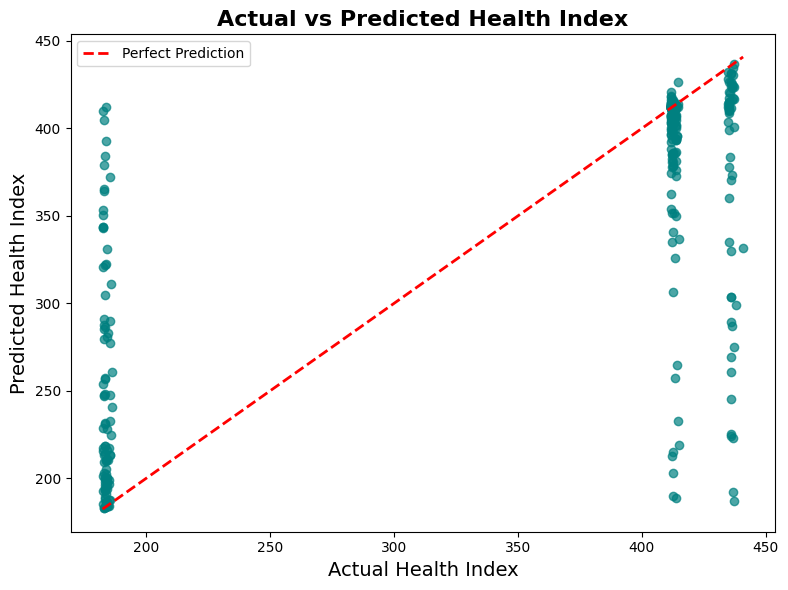

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

df = master_df.copy()
scaler = StandardScaler()
df['Ratio_65plus'] = df['population+65_country'] / df['population_country']
feature_cols = ['Inactivity_Prevalence', 'Smoking_Prevalence', 'AirPolution_Prevalence', 'Obesity_Prevalence', 'Diabetes_Prevalence','Ratio_65plus']

df['Health_Index'] = df[['NCD_Status','Beds_Per10000']].mean(axis=1)

df = df.dropna(subset=feature_cols + ['Health_Index'])

X = df[feature_cols]
y = df['Health_Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # <-- Fixed here
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Health Index', fontsize=14)
plt.ylabel('Predicted Health Index', fontsize=14)
plt.title('Actual vs Predicted Health Index', fontsize=16, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

✅**Q4-Can we estimate national healthcare needs by modeling the relationship between elderly population ratio, healthcare access, economic indicators, and tobacco control efforts?**

*Features:*

Ratio_65plus: Share of elderly population.

GDP_per_capita: Economic capacity.

Beds_Per10000: Healthcare infrastructure.

TobaccoCare: A health policy indicator related to tobacco control.

Target Variable:

Health_Index = average of NCD_Status (non-communicable disease burden), acting as a proxy for healthcare demand.

*Data Cleaning*
Drops rows with missing values in selected features and target.

*Modeling*
Train/Test Split: 80/20.

Model: XGBRegressor with:

100 trees, depth 5, learning rate 0.1.

*Evaluation*:

RMSE: How far predictions are from actual values.

R² Score: How well the model explains the variance.



RMSE: 130.7193
R2 Score: 0.6364
                              country  Predicted_Demand  Demand_per_million
4                 antigua and barbuda        866.958252         9338.197457
71                           kiribati        851.929382         6529.745628
60                          indonesia        848.311340            3.042390
67                              japan        843.198181            6.738847
0                         afghanistan        841.524719           20.738017
141                          viet nam        838.895813            8.415834
38                           djibouti        838.855103          737.717046
74   lao people's democratic republic        837.361206          110.776615
2                             algeria        837.145020           18.407939
115                        seychelles        836.630676         6979.017637


<ipython-input-22-1241194161>:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_total, x='Predicted_Demand', y='country', palette='Blues_d')
<ipython-input-22-1241194161>:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_per_million, x='Demand_per_million', y='country', palette='Greens_d')


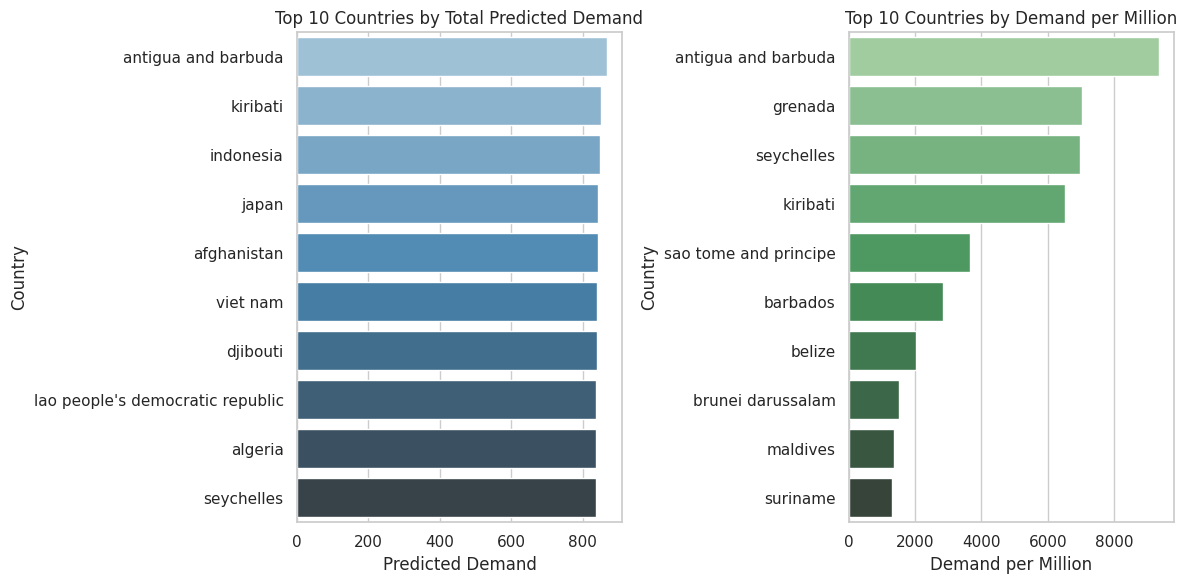

<Axes: xlabel='Predicted_Demand', ylabel='country'>

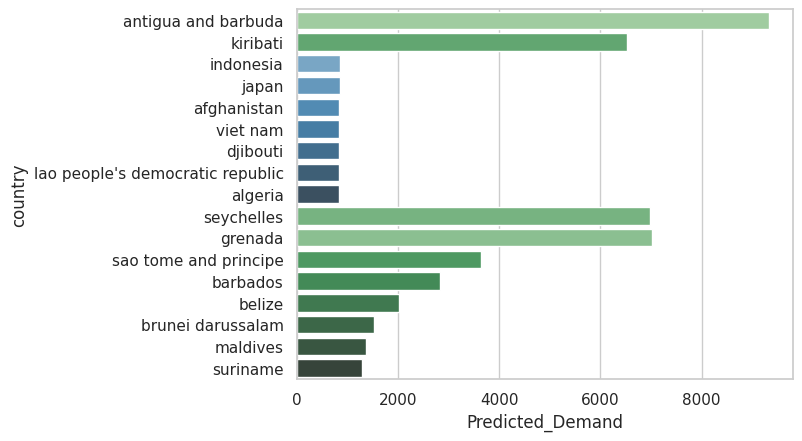

In [ ]:
df = master_df.copy()
scaler = StandardScaler()

# --- Feature Engineering---
df['Ratio_65plus'] = df['population+65_country'] / df['population_country']

# ---Features---
feature_cols = ['Ratio_65plus','GDP_per_capita','Beds_Per10000','TobaccoCare']
#Target
health_cols = ['NCD_Status']
df['Health_Index'] = master_df[health_cols].mean(axis=1)


# Remove Nan Records
df = df.dropna(subset=feature_cols + ['Health_Index'])

X = df[feature_cols]
y = df['Health_Index']

# Splite data to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  XGBoost Model
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Prediction on Test data
y_pred = model.predict(X_test)

# Model evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

# Features importance
#xgb.plot_importance(model)
#plt.show()

# Calculate the average of features for each country
df_avg = df.groupby('country')[feature_cols].mean().reset_index()

# Add the most recent population for each country
latest_pop = df[df['year'] == df['year'].max()][['country', 'population_country']]
df_avg = df_avg.merge(latest_pop, on='country', how='left')

# Predict using the trained model
X_avg = df_avg[feature_cols]
y_pred_avg = model.predict(X_avg)
df_avg['Predicted_Demand'] = y_pred_avg

# Demand per million people
df_avg['Demand_per_million'] = df_avg['Predicted_Demand'] / df_avg['population_country'] * 1_000_000

# Show the top 10 countries with the highest predicted demand
top10_avg = df_avg.sort_values('Predicted_Demand', ascending=False).head(10)
print(top10_avg[['country', 'Predicted_Demand', 'Demand_per_million']])



#Draw Graph
# set the graph shape
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# the top 10 countries with the highest predicted demand
top10_total = df_avg.sort_values('Predicted_Demand', ascending=False).head(10)

plt.subplot(1, 2, 1)
sns.barplot(data=top10_total, x='Predicted_Demand', y='country', palette='Blues_d')
plt.title("Top 10 Countries by Total Predicted Demand")
plt.xlabel("Predicted Demand")
plt.ylabel("Country")

# !0 Top Contries with highest demand
top10_per_million = df_avg.sort_values('Demand_per_million', ascending=False).head(10)

plt.subplot(1, 2, 2)
sns.barplot(data=top10_per_million, x='Demand_per_million', y='country', palette='Greens_d')
plt.title("Top 10 Countries by Demand per Million")
plt.xlabel("Demand per Million")
plt.ylabel("Country")

plt.tight_layout()
plt.show()
# First Graph
sns.barplot(
    data=top10_total,
    x='Predicted_Demand',
    y='country',
    hue='country',
    palette='Blues_d',
    legend=False
)

# Second Graph
sns.barplot(
    data=top10_per_million,
    x='Demand_per_million',
    y='country',
    hue='country',
    palette='Greens_d',
    legend=False
)


✅**Q5-Predicting Health Infrastructure Access from Age Demographics and Income across Countries**



*1- Feature Engineering*
Ratio_65plus: Elderly population ratio.

Ratio_young: Youth population (complement).

Beds_per_Elderly: Healthcare infrastructure adjusted for aging population.

Smoking_GDP_Interaction: Economic influence on smoking-related risk.

Health_Access_Index: Proxy for healthcare access from Beds_Per10000 and nursingper10000.

Health_Index: Used as the target variable for modeling.

*2-Model Training*
XGBoost Regressor is trained on 80% of data.

Evaluation metrics:

RMSE: Root Mean Square Error of prediction.

R² Score: Variance explained by the model.

Feature importance plot shows the most influential predictors.

*3. Country-Level Prediction*
Averaged input features are calculated per country.

Population data is merged to allow for normalization.

Model predicts Predicted_Demand for each country.

Demand_per_million: Normalized prediction per 1 million people.

RMSE: 5.7159
R2 Score: 0.9155


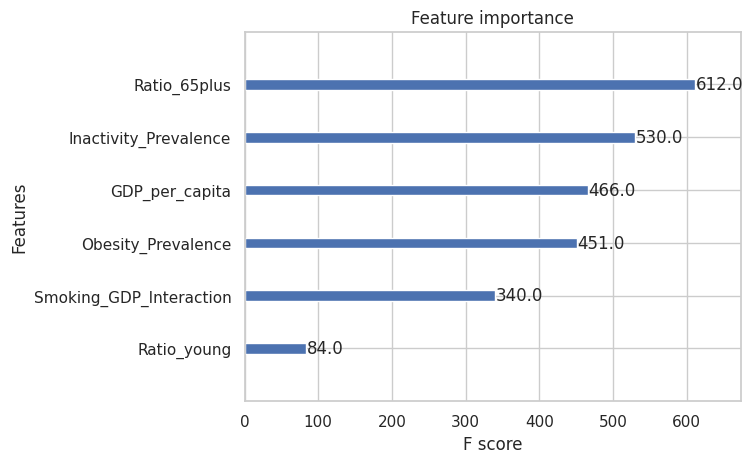

           country  Predicted_Demand  Demand_per_million
126    switzerland         92.834419           10.576904
97          norway         83.700272           15.337791
63         ireland         79.978111           15.482531
58         iceland         69.057037          180.776165
46         finland         65.564964           11.800524
7        australia         64.314262            2.472256
67           japan         64.216644            0.513220
78      luxembourg         64.078911           98.114556
138  united states         61.795849            0.185422
49         germany         61.328381            0.731860


<ipython-input-82-2177971268>:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_total, x='Predicted_Demand', y='country', palette='Blues_d')
<ipython-input-82-2177971268>:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_per_million, x='Demand_per_million', y='country', palette='Greens_d')


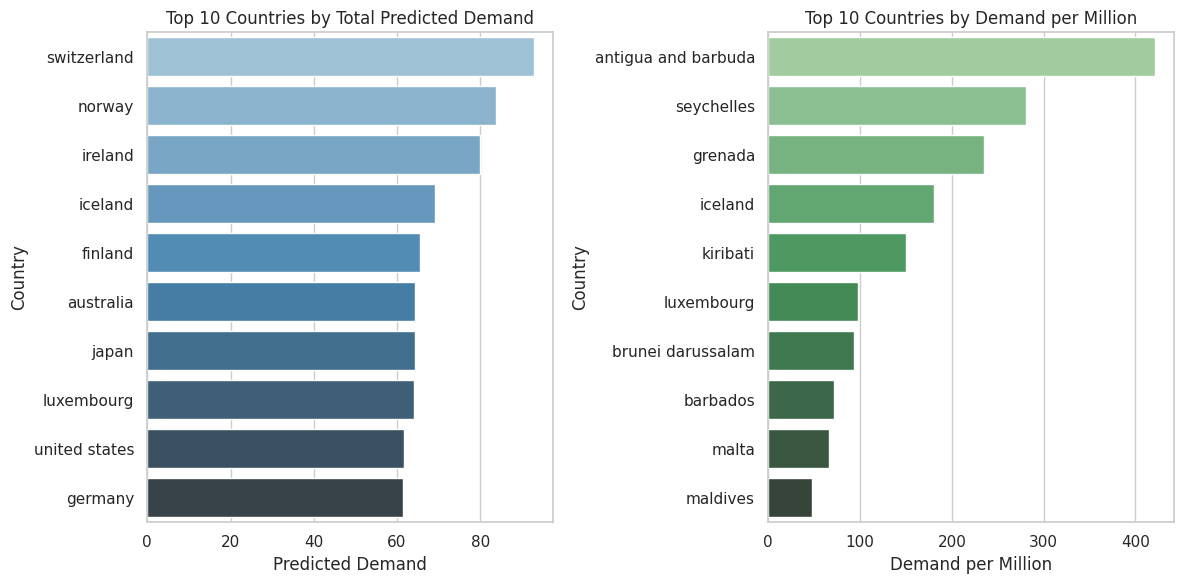

In [ ]:
df = master_df.copy()
scaler = StandardScaler()

# ---feature Engineering---
df['Ratio_65plus'] = df['population+65_country'] / df['population_country']
df['Ratio_young'] = 1 - df['Ratio_65plus']
df['Beds_per_Elderly'] = df['Beds_Per10000'] / df['population+65_country']
df['Smoking_GDP_Interaction'] = df['Smoking_Prevalence'] * df['GDP_per_capita']


df['Health_Access_Index'] = df[['Beds_Per10000','nursingper10000']].mean(axis=1)
df['Health_Index'] = df['Health_Access_Index']



# --- Featutes ---
feature_cols = ['Ratio_65plus', 'GDP_per_capita', 'Ratio_young','Smoking_GDP_Interaction','Inactivity_Prevalence','Obesity_Prevalence']


# Dropping Nan records
df = df.dropna(subset=feature_cols + ['Health_Index'])

X = df[feature_cols]
y = df['Health_Index']

# Splitting dataset to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#   XGBoost Model
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train th model
model.fit(X_train, y_train)

# Predicting on test data
y_pred = model.predict(X_test)

#  Evaluation model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

# Importance of features
xgb.plot_importance(model)
plt.show()



# Calculate the average features for each country
df_avg = df.groupby('country')[feature_cols].mean().reset_index()

# Add the latest countrie's population
latest_pop = df[df['year'] == df['year'].max()][['country', 'population_country']]
df_avg = df_avg.merge(latest_pop, on='country', how='left')

# Prediction with trained model
X_avg = df_avg[feature_cols]
y_pred_avg = model.predict(X_avg)
df_avg['Predicted_Demand'] = y_pred_avg

# Request per 1 milion
df_avg['Demand_per_million'] = df_avg['Predicted_Demand'] / df_avg['population_country'] * 1_000_000

# 10 Top countries with most predicted request
top10_avg = df_avg.sort_values('Predicted_Demand', ascending=False).head(10)
print(top10_avg[['country', 'Predicted_Demand', 'Demand_per_million']])

#Appearance features
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# --- Top 10 ---
top10_total = df_avg.sort_values('Predicted_Demand', ascending=False).head(10)

plt.subplot(1, 2, 1)
sns.barplot(data=top10_total, x='Predicted_Demand', y='country', palette='Blues_d')
plt.title("Top 10 Countries by Total Predicted Demand")
plt.xlabel("Predicted Demand")
plt.ylabel("Country")

# --- Top 10 ---
top10_per_million = df_avg.sort_values('Demand_per_million', ascending=False).head(10)

plt.subplot(1, 2, 2)
sns.barplot(data=top10_per_million, x='Demand_per_million', y='country', palette='Greens_d')
plt.title("Top 10 Countries by Demand per Million")
plt.xlabel("Demand per Million")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

✅**Q6- Is access to diabetes care equitable across countries with different income levels and health infrastructures?**

*1. Feature Engineering*
Ratio_65plus: Share of population aged 65 or older.

Ratio_young: Complement of above — younger population.

Health_Access_Index: Proxy for access to care, here based on Diabetes_Treatment.

Health_Index: Target variable (equal to Health_Access_Index for modeling convenience).

gender: One-hot encoded into gender_Male, gender_Female, etc.


*2. Feature Selection*
Selected predictive features include:

GDP_per_capita

Diabetes_Prevalence

Ratio_young, Ratio_65plus

Gender indicators from one-hot encoding

*3. Modeling*
Model Used: XGBoost Regressor

Parameters: 100 trees, max depth 5, learning rate 0.1

Data split: 80% training, 20% testing

*4. Model Evaluation*
RMSE (Root Mean Square Error): Measures prediction error

R² Score: Measures how much variance is explained by the model

*4. Interpretability*
XGBoost’s built-in plot_importance is used to visualize feature contributions to prediction.


RMSE: 5.7837
R2 Score: 0.8707


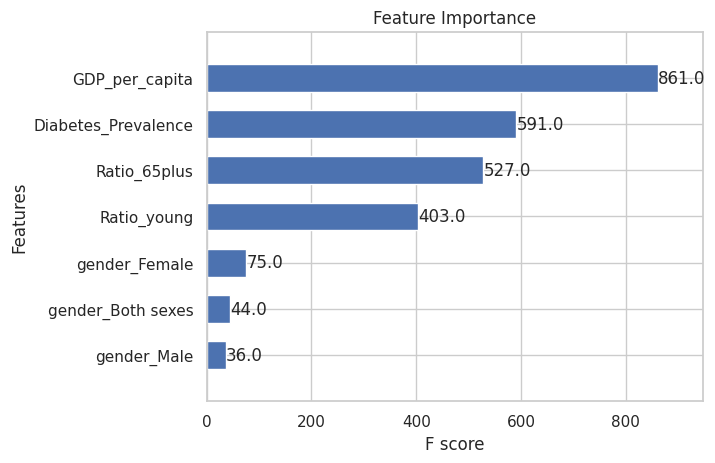

In [ ]:
df = master_df.copy()
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# --- Feature Engineering---
df['Ratio_65plus'] = df['population+65_country'] / df['population_country']
df['Ratio_young'] = 1 - df['Ratio_65plus']
#Target Feature
df['Health_Access_Index'] = df[['Diabetes_Treatment']].mean(axis=1)
df['Health_Index'] = df['Health_Access_Index']

df = pd.get_dummies(df, columns=['gender'])
# --- choose the Features---
feature_cols = ['GDP_per_capita', 'Diabetes_Prevalence','Ratio_young','Ratio_65plus']

# Add Gender to Features
feature_cols += [col for col in df.columns if col.startswith('gender_')]


# Remove Nan Records
df = df.dropna(subset=feature_cols + ['Health_Index'])

X = df[feature_cols]
y = df['Health_Index']

# Split data to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost Model
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train the Model
model.fit(X_train, y_train)

# Predict on Test Data
y_pred = model.predict(X_test)

# Evaluate Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

import matplotlib.pyplot as plt
xgb.plot_importance(model, height=0.6)
plt.title("Feature Importance")
plt.show()

✅***Q7-Can we predict a country's Health Access Index using demographic, behavioral risk factors, and economic indicators?***

*1. Feature Engineering*
Ratio_65plus: Proportion of population aged 65+.

Ratio_young: Youth proportion (1 - Ratio_65plus).

Health_Access_Index: Created by averaging diabetes treatment coverage and hospital beds per capita.

Health_Index: Used as the target variable for prediction.

*2. One-Hot Encoding*
gender is encoded into multiple binary columns like gender_Male, gender_Female, etc.

*3. Data Scaling & Splitting*
StandardScaler is used to normalize the data.

Data is split into training and test sets (80/20 split).

*4. Model Training & Evaluation*
A model (assumed to be already defined, e.g. MLPRegressor) is trained.

RMSE and R² Score are printed to evaluate prediction accuracy.

*5. Country-Level Health Index Visualization*
Average Health_Index is calculated per country for years after 2021.

Top 10 countries with the highest health index are shown using a bar chart.



RMSE: 2.3336
R2 Score: 0.9232
      year      country  Health_Index
1444  2022      belgium        40.995
1535  2022       poland        39.645
1476  2022      finland        38.415
1550  2022  south korea        38.155
1479  2022      germany        36.120
1536  2022     portugal        36.000
1498  2022       jordan        35.575
1551  2022        spain        35.440
1462  2022   costa rica        35.265
1513  2022        malta        34.740


<ipython-input-25-2342885358>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_2015, x='Health_Index', y='country', palette='viridis')


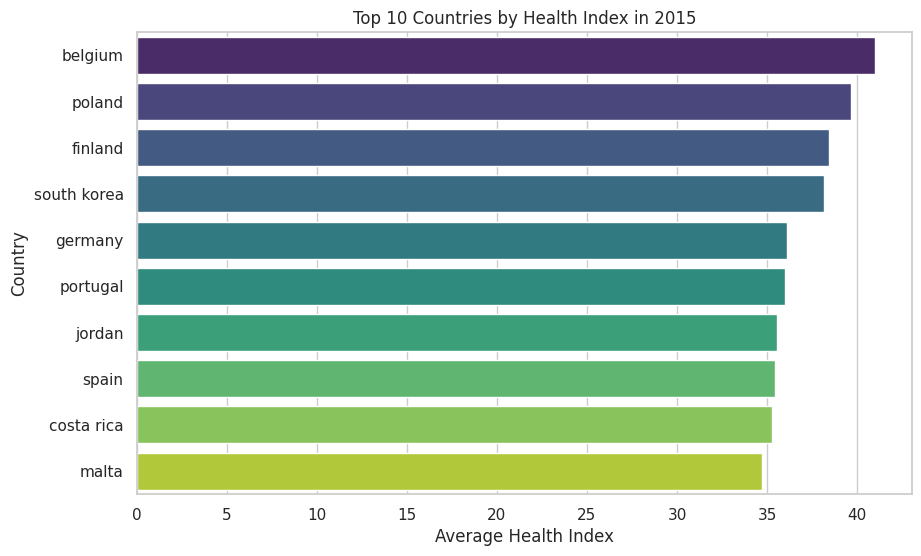

In [ ]:
df = master_df.copy()
scaler = StandardScaler()

# --- Feature Engineering---
df['Ratio_65plus'] = df['population+65_country'] / df['population_country']
df['Ratio_young'] = 1 - df['Ratio_65plus']
#Target Feature
df['Health_Access_Index'] = df[['Diabetes_Treatment','Beds_Per10000']].mean(axis=1)
df['Health_Index'] = df['Health_Access_Index']

df = pd.get_dummies(df, columns=['gender'])

# --- Selected Features ---
feature_cols = ['GDP_per_capita', 'Diabetes_Prevalence','Ratio_65plus','Obesity_Prevalence','Inactivity_Prevalence' ]

# Add Gender to Features
feature_cols += [col for col in df.columns if col.startswith('gender_')]

# Remove Nan Records
df = df.dropna(subset=feature_cols + ['Health_Index'])

X = df[feature_cols]
y = df['Health_Index']

# Split data to train and test
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# X_scaled
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

#10 Top Countries
df_avg_year = df.groupby(['year', 'country'])['Health_Index'].mean().reset_index()

# 10 Top countries since 2021
top10_2015 = df_avg_year[df_avg_year['year'] > 2021].sort_values(by='Health_Index', ascending=False).head(10)
print(top10_2015)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=top10_2015, x='Health_Index', y='country', palette='viridis')
plt.title('Top 10 Countries by Health Index in 2015')
plt.xlabel('Average Health Index')
plt.ylabel('Country')
plt.show()


✅***Q8-What role do demographics of youth play in shaping tobacco-related health outcomes?***


**Feature Engineering:**

Ratio_65plus: proportion of population aged 65+.

Ratio_young: 1 minus elderly ratio.

Smoking_Prevalence_Percent: normalized smoking prevalence.

Smoking_x_Young / Smoking_x_Eldery: interaction terms to capture how smoking affects young and elderly populations.

Ratio_young_to_elderly: demographic balance metric.

GDP_per_capita_per_Youth: GDP burden on young population.

**Model Inputs:**

Features selected include GDP, healthcare (beds), smoking-age interactions, gender dummies, and demographic ratios.

**Model Training:**

XGBoost regression model is trained to predict Health_Index.

RMSE and R² are computed for performance.

Feature importance is visualized.

XGBoost RMSE: 0.3440
XGBoost R2: 0.7441


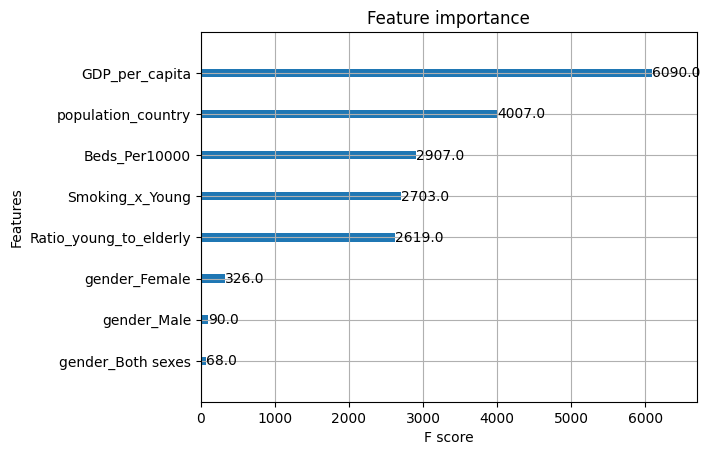

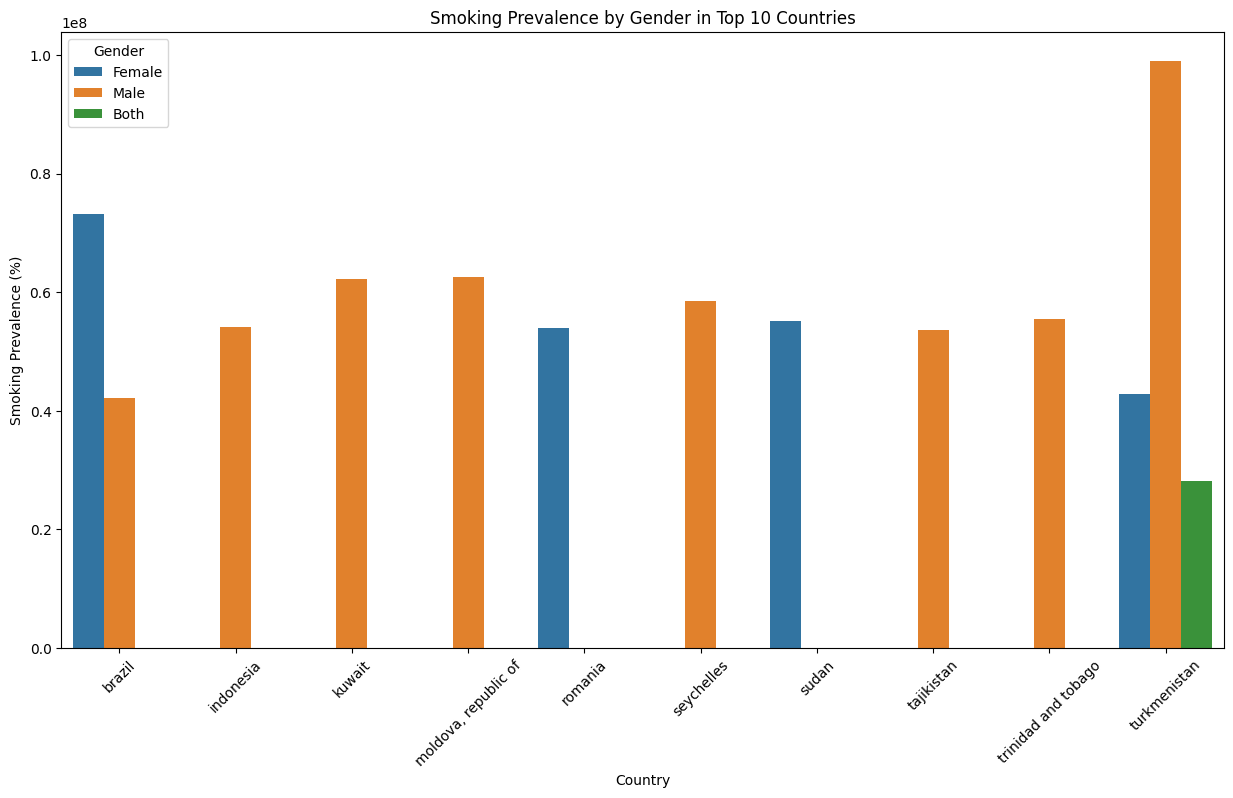

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = master_df.copy()

df = pd.get_dummies(df, columns=['gender'])
def infer_gender(row):
    if row['gender_Male'] == 1:
        return 'Male'
    elif row['gender_Female'] == 1:
        return 'Female'
    elif row['gender_Both sexes'] == 1:
        return 'Both'
    else:
        return 'Unknown'

df['gender'] = df.apply(infer_gender, axis=1)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# --- Feature Engineering---
df['Ratio_65plus'] = df['population+65_country'] / df['population_country']
df['Ratio_young'] = 1 - df['Ratio_65plus']
df['Smoking_Prevalence_Percent'] = df['Smoking_Prevalence'] / df['population_country'] * 100
df['Smoking_x_Young'] = df['Smoking_Prevalence_Percent'] * df['Ratio_young']
df['Smoking_x_Eldery'] = df['Smoking_Prevalence_Percent'] * df['Ratio_65plus']
df['Ratio_young_to_elderly'] = df['Ratio_young'] / (df['Ratio_65plus'] + 1e-6)
df['GDP_per_capita_per_Youth'] = df['GDP_per_capita'] / df['Ratio_young']

# --- Select Features---
feature_cols = ['GDP_per_capita' , 'population_country' , 'Smoking_x_Young' , 'Beds_Per10000' , 'Ratio_young_to_elderly']
# Add Gender to features
feature_cols += [col for col in df.columns if col.startswith('gender_')]

#Target Feature
df['Health_Index'] = df['TobaccoCare']

# Remove Nan Records
df = df.dropna(subset=feature_cols + ['Health_Index'])

X = df[feature_cols]
y = df['Health_Index']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)

# Split data to test and train
import xgboost as xgb
model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost RMSE: {rmse:.4f}")
print(f"XGBoost R2: {r2:.4f}")


import matplotlib.pyplot as plt
xgb.plot_importance(model)
plt.show()


# Average smoking rate by country and gender for each year
df_grouped = df.groupby(['country', 'gender'])['Smoking_Prevalence'].mean().reset_index()

# Select the top 10 countries with the highest overall smoking rate (average across all genders)
top_countries = df_grouped.groupby('country')['Smoking_Prevalence'].mean().nlargest(10).index
df_top = df_grouped[df_grouped['country'].isin(top_countries)]

# Draw Graph
plt.figure(figsize=(15,8))
sns.barplot(data=df_top, x='country', y='Smoking_Prevalence', hue='gender')
#plt.title('Smoking Prevalence by Gender in Top 10 Countries')
plt.xticks(rotation=45)
plt.ylabel('Smoking Prevalence (%)')
plt.xlabel('Country')
plt.legend(title='Gender')
plt.show()



In [ ]:
#Ganth chart
!pip install plotly

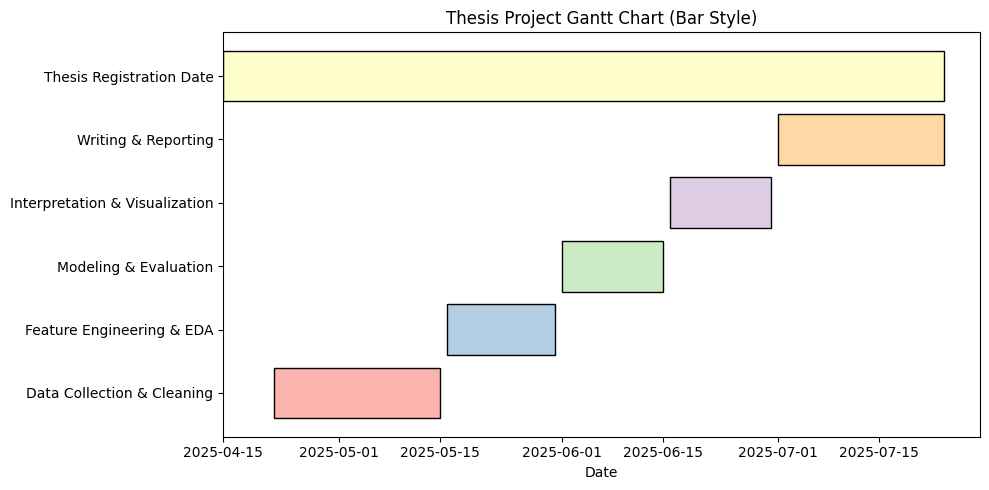

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import datetime

# Define your Gantt chart tasks and dates
tasks = [
    ("Data Collection & Cleaning", '2025-04-22', '2025-05-15'),
    ("Feature Engineering & EDA", '2025-05-16', '2025-05-31'),
    ("Modeling & Evaluation", '2025-06-01', '2025-06-15'),
    ("Interpretation & Visualization", '2025-06-16', '2025-06-30'),
    ("Writing & Reporting", '2025-07-01', '2025-07-24'),
    ("Thesis Registration Date", '2025-04-15', '2025-07-24'),
]

# Convert to DataFrame
df = pd.DataFrame(tasks, columns=["Task", "Start", "Finish"])
df["Start"] = pd.to_datetime(df["Start"])
df["Finish"] = pd.to_datetime(df["Finish"])
df["Duration"] = (df["Finish"] - df["Start"]).dt.days

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Pastel1(range(len(df)))

for i, row in df.iterrows():
    ax.barh(row["Task"], row["Duration"], left=row["Start"], color=colors[i], edgecolor='k')

ax.set_xlabel('Date')
ax.set_title('Thesis Project Gantt Chart (Bar Style)')
plt.tight_layout()
plt.show()